모듈 생성

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader


전처리 선언하기

In [2]:
# CIFAR-100 전처리 (학습용: 증강 포함)
train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),           # 좌우 반전 (데이터 증강)
    transforms.RandomCrop(32, padding=4),        # 랜덤 크롭
    transforms.ToTensor(),
   transforms.Normalize((0.5071, 0.4867, 0.4408), # CIFAR-100 RGB 평균
                         (0.2675, 0.2565, 0.2761))
])
test_transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5071, 0.4867, 0.4408),
                         (0.2675, 0.2565, 0.2761))
])

데이터셋 불러오기

In [3]:
train_dataset = datasets.CIFAR100('./data', train=True,  download=True, transform=train_transform)
test_dataset  = datasets.CIFAR100('./data', train=False, download=True, transform=test_transform)

data Loder 준비하기

In [4]:
train_loader = DataLoader(train_dataset, batch_size=128, shuffle=True,  num_workers=2)
test_loader  = DataLoader(test_dataset,  batch_size=128, shuffle=False, num_workers=2)


클래스 분류 정의하기

In [5]:
classes = train_dataset.classes # CIFAR-100의 100개 클래스 이름 자동 할당

print(f"학습 데이터: {len(train_dataset)}장")
print(f"테스트 데이터: {len(test_dataset)}장")

학습 데이터: 50000장
테스트 데이터: 10000장


모델 설계

In [6]:
class CIFAR_CNN(nn.Module):
    def __init__(self):
        super().__init__()
        # 합성곱 블록 1: 3채널 → 32채널
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 32×32 → 16×16
        )
        # 합성곱 블록 2: 32채널 → 64채널
        self.block2 = nn.Sequential(
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 16×16 → 8×8
        )
        # 합성곱 블록 3: 64채널 → 128채널
        self.block3 = nn.Sequential(
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.MaxPool2d(2, 2)   # 8×8 → 4×4
        )
        # 완전연결층
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 512),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(512, 100)
        )

    def forward(self, x):
        x = self.block1(x)
        x = self.block2(x)
        x = self.block3(x)
        x = self.classifier(x)
        return x


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CIFAR_CNN().to(device)

total_params = sum(p.numel() for p in model.parameters())
print(f"파라미터 수: {total_params:,}")

파라미터 수: 1,194,084


학습 실행

In [8]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    total_loss = 0.0
    correct = 0

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset) * 100
    return avg_loss, accuracy


def evaluate(model, loader, criterion, device):
    model.eval()
    total_loss = 0.0
    correct = 0

    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)
            _, predicted = outputs.max(1)
            correct += predicted.eq(labels).sum().item()

    avg_loss = total_loss / len(loader.dataset)
    accuracy = correct / len(loader.dataset) * 100
    return avg_loss, accuracy


criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

EPOCHS = 20
best_acc = 0
save_path = 'best_cifar100_model.pth'

for epoch in range(1, EPOCHS + 1):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer, device)
    test_loss, test_acc = evaluate(model, test_loader, criterion, device)

    print(f"Epoch {epoch:2d}/{EPOCHS} | "
          f"Train Loss: {train_loss:.4f} Acc: {train_acc:.1f}% | "
          f"Test Loss: {test_loss:.4f} Acc: {test_acc:.1f}%")

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), save_path)


print(f"\n최고 테스트 정확도: {best_acc:.2f}%")


Epoch  1/20 | Train Loss: 3.3962 Acc: 17.2% | Test Loss: 2.9732 Acc: 25.3%
Epoch  2/20 | Train Loss: 3.1850 Acc: 20.8% | Test Loss: 2.7744 Acc: 29.6%
Epoch  3/20 | Train Loss: 3.0393 Acc: 23.6% | Test Loss: 2.6387 Acc: 32.3%
Epoch  4/20 | Train Loss: 2.9324 Acc: 25.8% | Test Loss: 2.4863 Acc: 34.9%
Epoch  5/20 | Train Loss: 2.8604 Acc: 26.9% | Test Loss: 2.4333 Acc: 35.5%
Epoch  6/20 | Train Loss: 2.7813 Acc: 28.3% | Test Loss: 2.3799 Acc: 37.2%
Epoch  7/20 | Train Loss: 2.7220 Acc: 29.7% | Test Loss: 2.3852 Acc: 37.3%
Epoch  8/20 | Train Loss: 2.6713 Acc: 30.5% | Test Loss: 2.2951 Acc: 40.1%
Epoch  9/20 | Train Loss: 2.6287 Acc: 31.5% | Test Loss: 2.2354 Acc: 40.3%
Epoch 10/20 | Train Loss: 2.5861 Acc: 32.5% | Test Loss: 2.1522 Acc: 41.7%
Epoch 11/20 | Train Loss: 2.5351 Acc: 33.6% | Test Loss: 2.1783 Acc: 41.8%
Epoch 12/20 | Train Loss: 2.5020 Acc: 34.1% | Test Loss: 2.1072 Acc: 43.3%
Epoch 13/20 | Train Loss: 2.4723 Acc: 35.2% | Test Loss: 2.1018 Acc: 43.4%
Epoch 14/20 | Train Loss:

첫 번째 레이어 필터 시각화

필터 shape: torch.Size([32, 3, 3, 3])


/tmp/ipykernel_41946/81868334.py:21: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/81868334.py:21: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/81868334.py:21: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/81868334.py:21: UserWarning: Glyph 54633 (\N{HANGUL SYLLABLE HAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/81868334.py:21: UserWarning: Glyph 49457 (\N{HANGUL SYLLABLE SEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/81868334.py:21: UserWarning: Glyph 44273 (\N{HANGUL SYLLABLE GOB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/81868334.py:21: UserWarning: Glyph 47112 (\N{HANGUL SYLLABLE RE}) missing from font(s) DejaVu Sans.
  plt.tight_layo

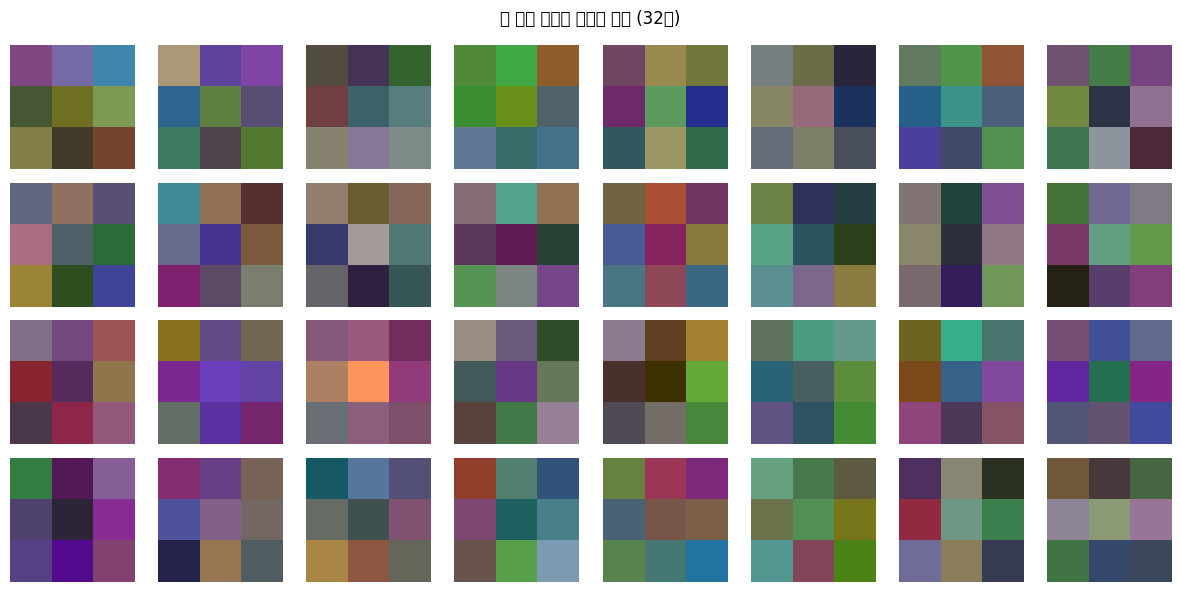

In [9]:
import matplotlib.pyplot as plt
import numpy as np

# 학습된 모델의 첫 번째 Conv 레이어 가중치
weights = model.block1[0].weight.data.cpu()  # [32, 3, 3, 3]
print(f"필터 shape: {weights.shape}")  # [필터수, 채널, H, W]

# 필터 정규화 (시각화용)
w_min, w_max = weights.min(), weights.max()
weights = (weights - w_min) / (w_max - w_min)

# 32개 필터 시각화
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < weights.shape[0]:
        # RGB 채널 합성 (3채널 → 시각화)
        filt = weights[i].permute(1, 2, 0).numpy()  # [3,3,3] → [3,3,3] HWC
        ax.imshow(filt)
    ax.axis('off')
plt.suptitle("첫 번째 합성곱 레이어 필터 (32개)", fontsize=12)
plt.tight_layout()
plt.show()


특징 맵 시각화

/tmp/ipykernel_41946/853677500.py:30: UserWarning: Glyph 54596 (\N{HANGUL SYLLABLE PIL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/853677500.py:30: UserWarning: Glyph 53552 (\N{HANGUL SYLLABLE TEO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/853677500.py:30: UserWarning: Glyph 50896 (\N{HANGUL SYLLABLE WEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/853677500.py:30: UserWarning: Glyph 48376 (\N{HANGUL SYLLABLE BON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/853677500.py:30: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/853677500.py:30: UserWarning: Glyph 48264 (\N{HANGUL SYLLABLE BEON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/853677500.py:30: UserWarning: Glyph 51704 (\N{HANGUL SYLLABLE JJAE}) missing from font(s) DejaVu Sans.
  plt.tig

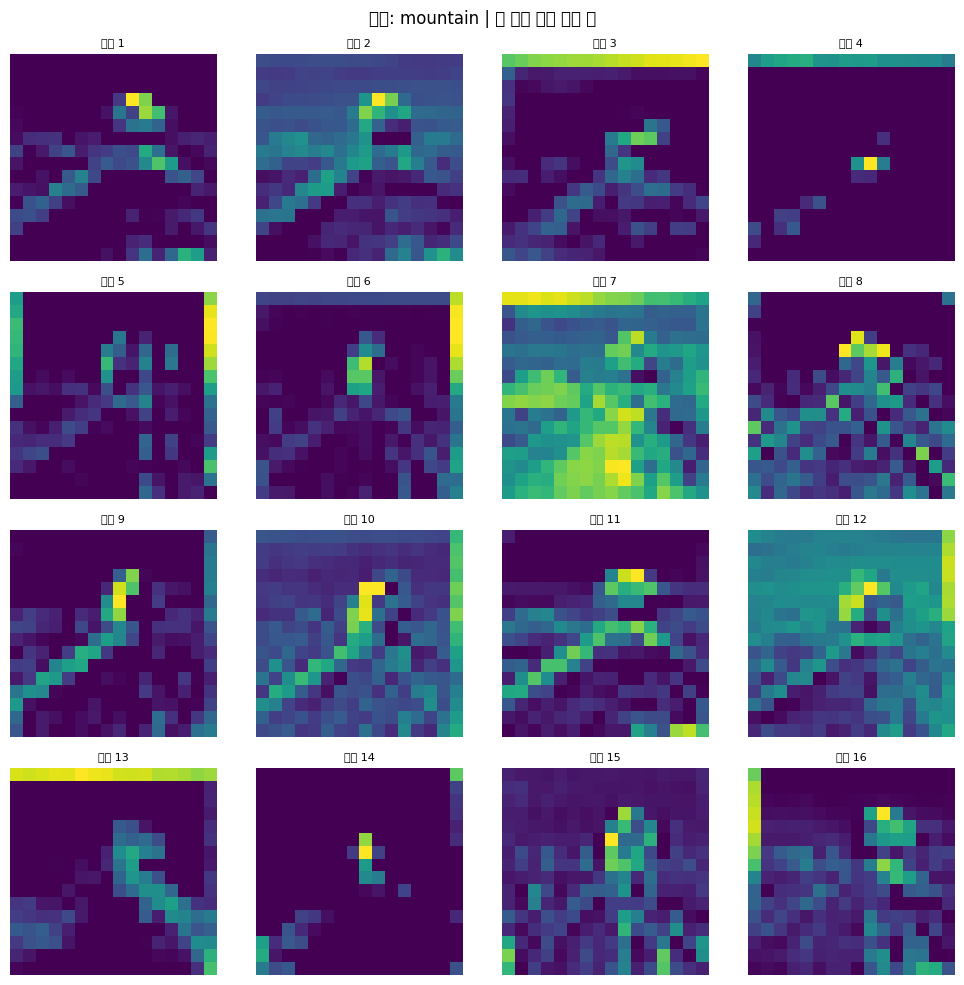

In [10]:
# 테스트 이미지 1장 가져오기
image, label = test_dataset[0]
image_tensor = image.unsqueeze(0).to(device)  # [1, 3, 32, 32]

# 첫 번째 블록의 출력 추출 (hook 사용)
feature_maps = {}

def hook_fn(module, input, output):
    feature_maps['block1'] = output.detach().cpu()

hook = model.block1.register_forward_hook(hook_fn)

# 순전파 실행
model.eval()
with torch.no_grad():
    _ = model(image_tensor)

hook.remove()

# 특징 맵 시각화 (32개 채널 중 16개)
fmaps = feature_maps['block1'][0]  # [32, 16, 16]
fig, axes = plt.subplots(4, 4, figsize=(10, 10))
for i, ax in enumerate(axes.flat):
    ax.imshow(fmaps[i].numpy(), cmap='viridis')
    ax.set_title(f"필터 {i+1}", fontsize=8)
    ax.axis('off')

# 원본 이미지도 함께 표시
plt.suptitle(f"원본: {classes[label]} | 첫 번째 블록 특징 맵", fontsize=12)
plt.tight_layout()
plt.show()


클래스별 예측 확인

/tmp/ipykernel_41946/2593054829.py:26: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/2593054829.py:26: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/2593054829.py:26: UserWarning: Glyph 53364 (\N{HANGUL SYLLABLE KEUL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/2593054829.py:26: UserWarning: Glyph 47000 (\N{HANGUL SYLLABLE RAE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/2593054829.py:26: UserWarning: Glyph 49828 (\N{HANGUL SYLLABLE SEU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/2593054829.py:26: UserWarning: Glyph 48324 (\N{HANGUL SYLLABLE BYEOL}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/2593054829.py:26: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
 

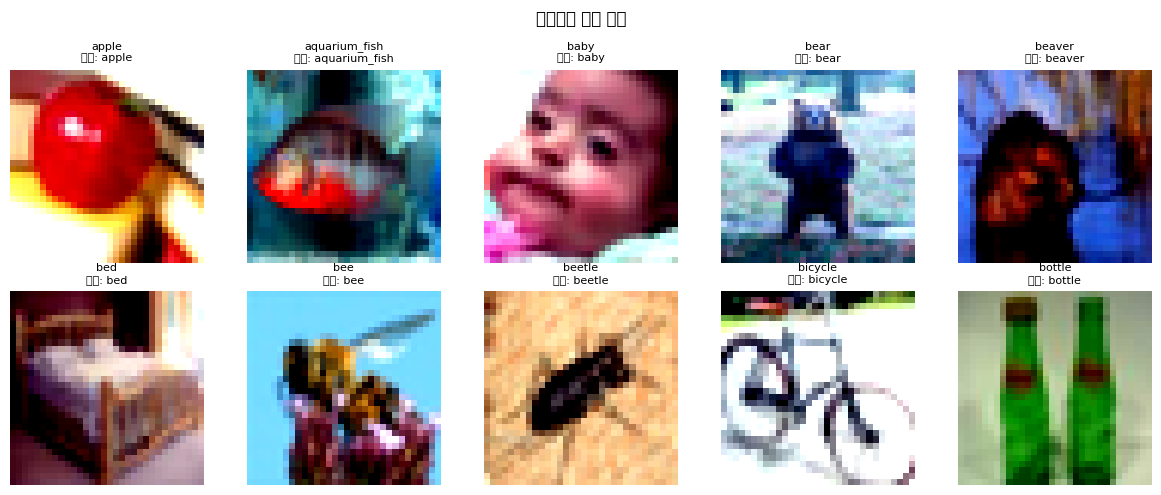

In [11]:
# 각 클래스별로 올바르게 예측한 예시와 틀린 예시 시각화
model.eval()
class_correct = {c: [] for c in classes}
class_wrong   = {c: [] for c in classes}

with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.max(1)[1].cpu()
        for img, true, pred in zip(images, labels, preds):
            cls = classes[true.item()]
            if true == pred and len(class_correct[cls]) < 2:
                class_correct[cls].append((img, pred.item()))
            elif true != pred and len(class_wrong[cls]) < 2:
                class_wrong[cls].append((img, pred.item()))

# 클래스별 맞춘 사례 시각화
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, (cls, ax) in enumerate(zip(classes, axes.flat)):
    if class_correct[cls]:
        img, pred = class_correct[cls][0]
        ax.imshow(img.permute(1, 2, 0).numpy() * 0.5 + 0.5)
        ax.set_title(f"{cls}\n예측: {classes[pred]}", fontsize=8)
    ax.axis('off')
plt.suptitle("클래스별 정답 예시", fontsize=12)
plt.tight_layout()
plt.show()


혼동 행렬로 오류 분석

In [12]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

all_preds, all_labels = [], []
model.eval()
with torch.no_grad():
    for images, labels in test_loader:
        outputs = model(images.to(device))
        preds = outputs.max(1)[1].cpu()
        all_preds.extend(preds.numpy())
        all_labels.extend(labels.numpy())

cm = confusion_matrix(all_labels, all_preds)

plt.figure(figsize=(100, 80))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes, yticklabels=classes)
plt.xlabel('예측')
plt.ylabel('정답')
plt.title('CIFAR-100 혼동 행렬')
plt.tight_layout()
plt.show()


/tmp/ipykernel_41946/1006490905.py:21: UserWarning: Glyph 50696 (\N{HANGUL SYLLABLE YE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/1006490905.py:21: UserWarning: Glyph 52769 (\N{HANGUL SYLLABLE CEUG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/1006490905.py:21: UserWarning: Glyph 51221 (\N{HANGUL SYLLABLE JEONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/1006490905.py:21: UserWarning: Glyph 45813 (\N{HANGUL SYLLABLE DAB}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/1006490905.py:21: UserWarning: Glyph 54844 (\N{HANGUL SYLLABLE HON}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/1006490905.py:21: UserWarning: Glyph 46041 (\N{HANGUL SYLLABLE DONG}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_41946/1006490905.py:21: UserWarning: Glyph 54665 (\N{HANGUL SYLLABLE HAENG}) missing from font(s) DejaVu Sans.
 